## 3. Aer Estimator - qiskit_aer

---

In [43]:
import time
import pprint

from qiskit import QuantumCircuit, schedule
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer import *
from qiskit_aer import noise

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

In [2]:
simulator_basic = BasicSimulator()
simulator_aer = AerSimulator()

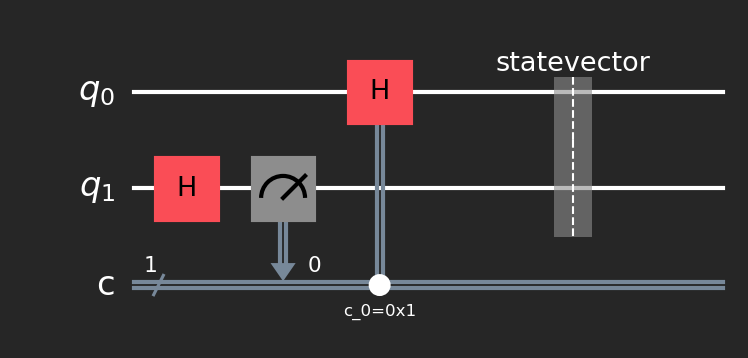

In [3]:
qc = QuantumCircuit(2,1)
qc.h(1)
qc.measure(1,0)
qc.h(0).c_if(0,1)
qc.save_statevector()
qc.draw()

In [4]:
result = simulator_aer.run(transpile(qc, simulator_aer)).result()
print(result.get_counts())

{'0': 549, '1': 475}


In [5]:
for a in range(5):
    result = simulator_aer.run(qc).result()
    ψ = result.get_statevector()
    display(ψ)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

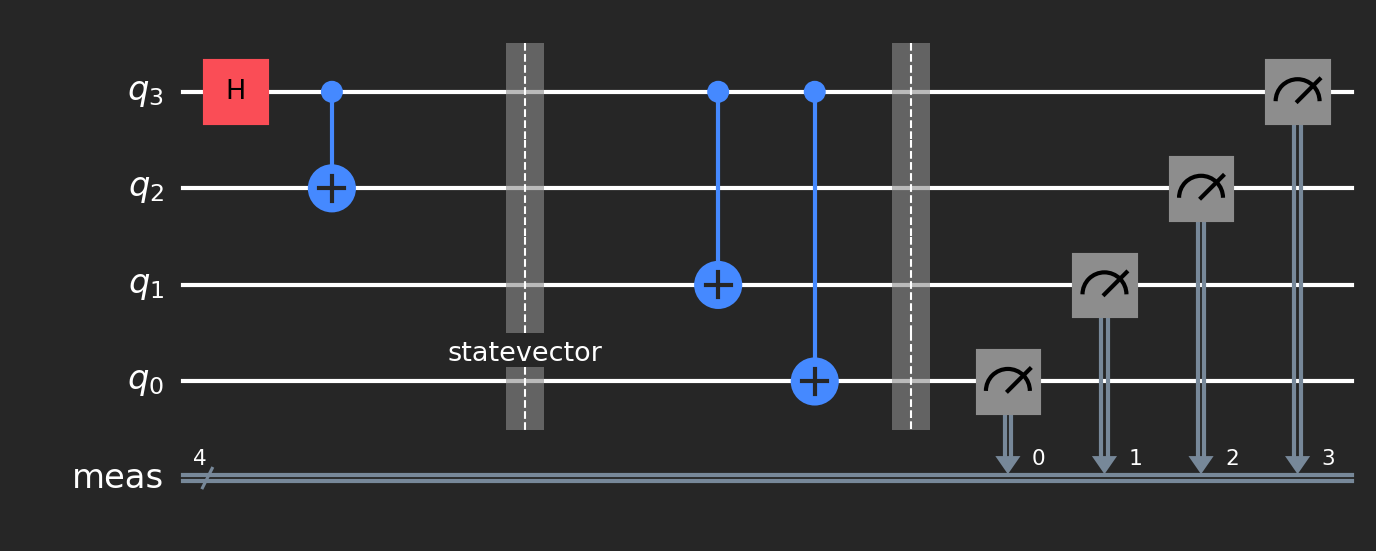

In [6]:
qc = QuantumCircuit(4)
qc.h(3)
qc.cx(3,2)
qc.save_statevector()
qc.cx(3,1)
qc.cx(3,0)
qc.measure_all()
qc.draw(reverse_bits = True)

In [7]:
qc_aer = transpile(qc, backend=simulator_aer)

result = simulator_aer.run(qc_aer).result()
ψ = result.get_statevector()
ψ

<IPython.core.display.Latex object>

## Simulators

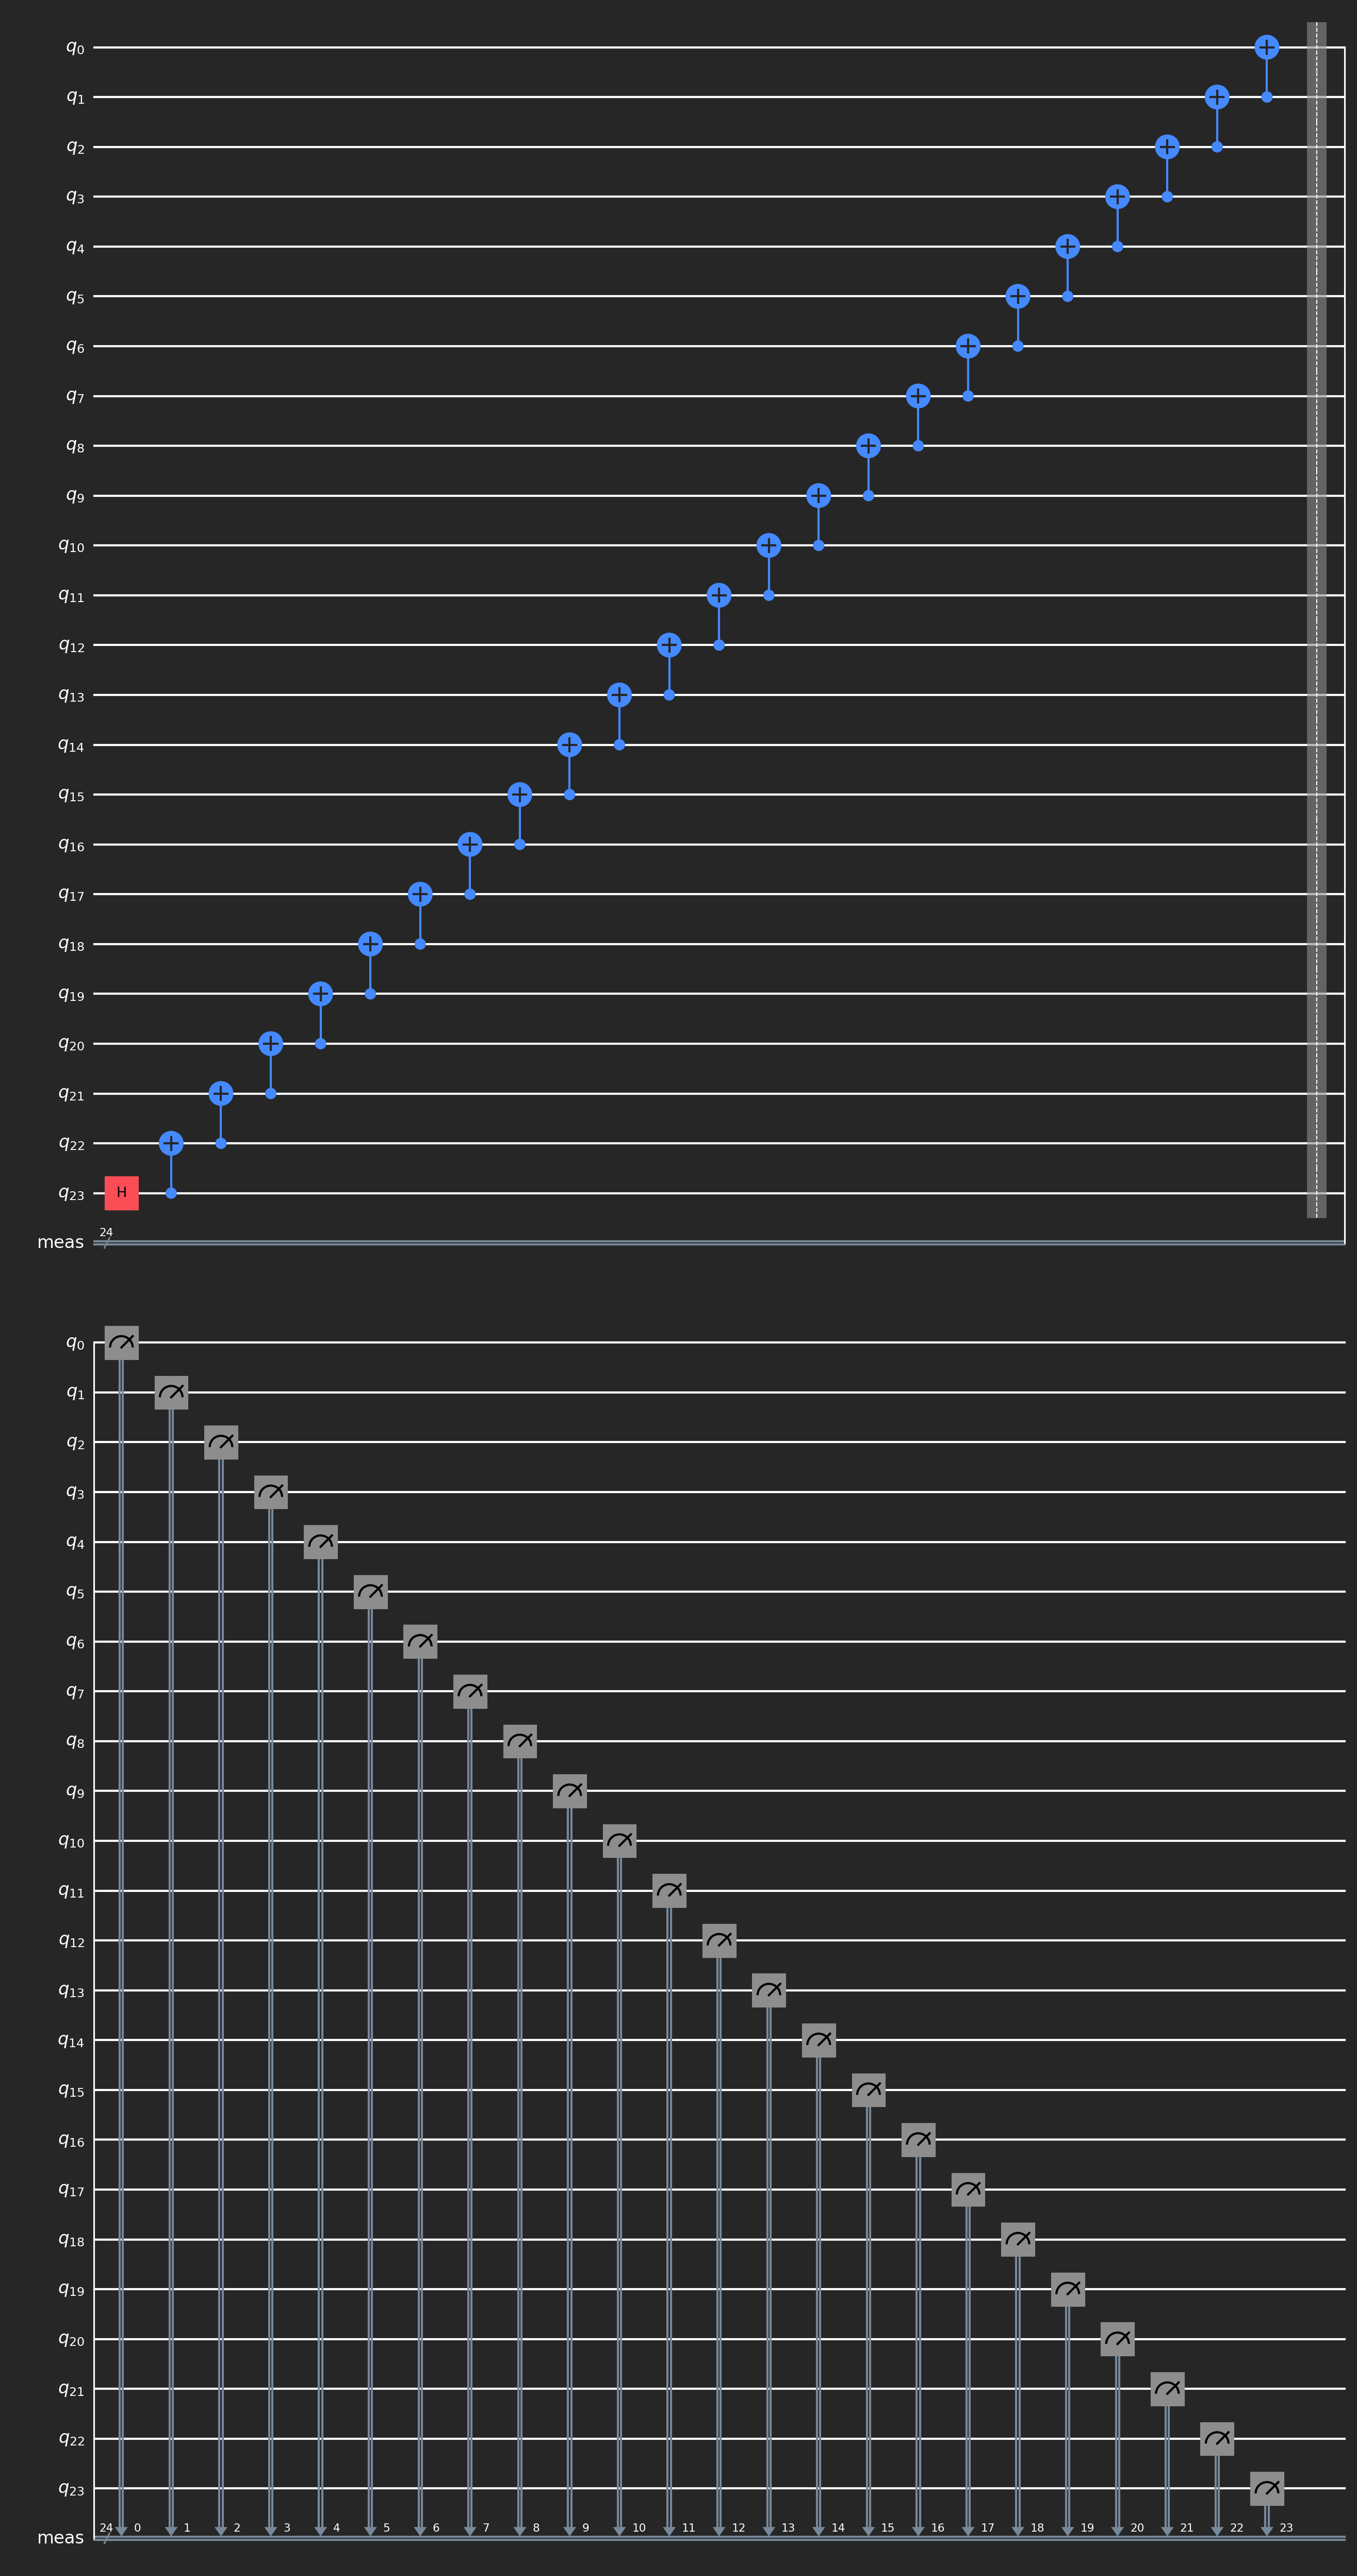

In [8]:
n = 24
qc = QuantumCircuit(n)
qc.h(n-1)
for i in range(n-1,0,-1):
    qc.cx(i,i-1)

qc.measure_all()
qc.draw()

In [9]:
%%time 

result = simulator_basic.run(qc, shots = 1024).result()
counts = result.get_counts()
print(counts)

{'111111111111111111111111': 511, '000000000000000000000000': 513}
CPU times: user 5.62 s, sys: 1.1 s, total: 6.72 s
Wall time: 6.72 s


In [10]:
%%time 

result = simulator_aer.run(qc, shots = 1024, method='statevector').result()
counts = result.get_counts()
print(counts)

{'111111111111111111111111': 516, '000000000000000000000000': 508}
CPU times: user 3.03 s, sys: 558 ms, total: 3.59 s
Wall time: 227 ms


In [11]:
%%time 

result = simulator_aer.run(qc, shots = 1024, method='matrix_product_state').result()
counts = result.get_counts()
print(counts)

{'000000000000000000000000': 526, '111111111111111111111111': 498}
CPU times: user 208 ms, sys: 193 ms, total: 401 ms
Wall time: 26 ms


## Noise

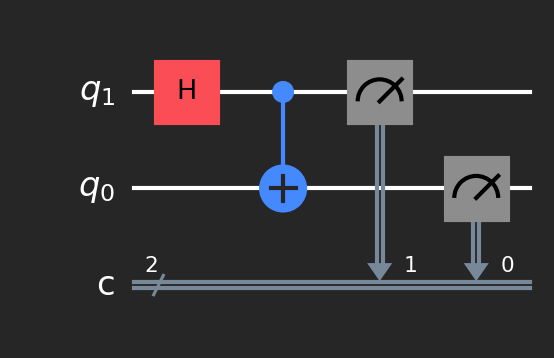

In [12]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.cx(1,0)
qc.measure([1,0],[1,0])
qc.draw(reverse_bits = True)

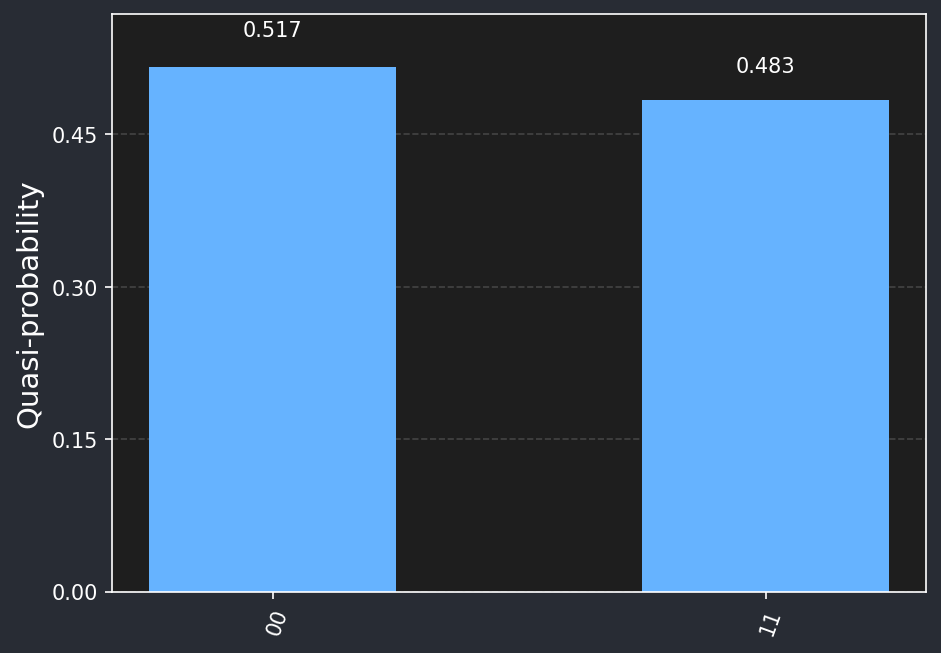

In [13]:
qc_aer = transpile(qc, backend=simulator_aer)
result_ideal = simulator_aer.run(qc_aer, shots = 1024).result()
counts_ideal = result_ideal.get_counts()
plot_distribution(counts_ideal, color = ['#66b3ff'])

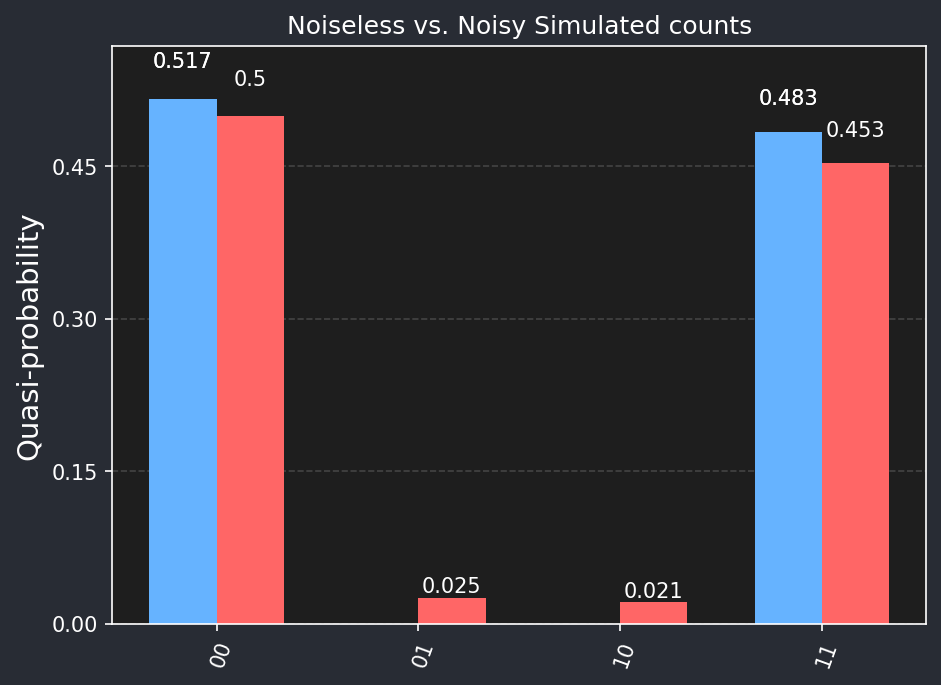

In [14]:
prob = 0.1
error = noise.depolarizing_error(prob, 2)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cx'])
basis_gates = noise_model.basis_gates

result_noisy = simulator_aer.run(qc,
                                 shots = 1024,
                                 noise_model=noise_model,
                                 basis_gates=basis_gates).result()

counts_noisy = result_noisy.get_counts()
plot_distribution([counts_ideal, counts_noisy], title='Noiseless vs. Noisy Simulated counts', color = ['#66b3ff', "#ff6666"])


### Imitando QC Reais - ibm_brisbane

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
real_backend = service.backend("ibm_brisbane")

In [16]:
noisy_simulator = AerSimulator.from_backend(real_backend)
simulator_aer = AerSimulator()

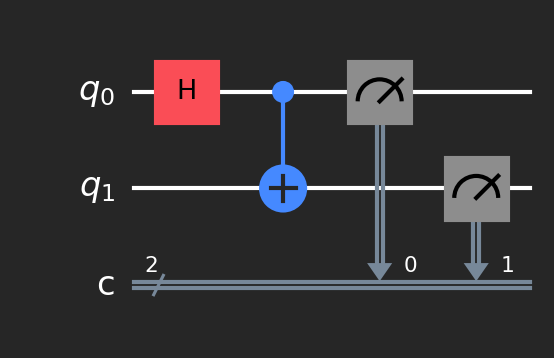

In [ ]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw()

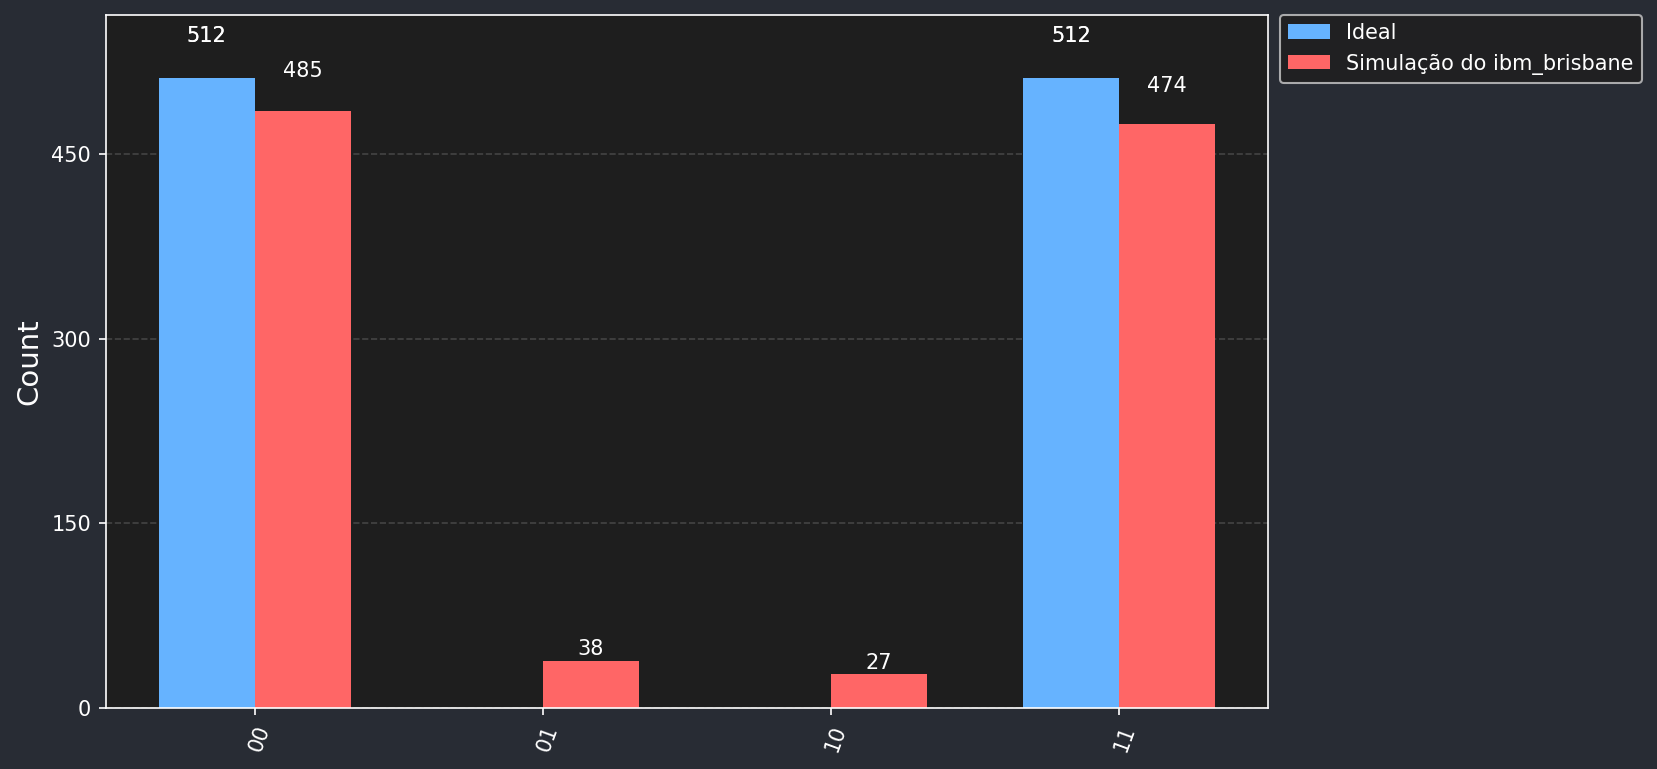

In [ ]:
qc_aer = transpile(qc, backend=simulator_aer)
result_ideal = simulator_aer.run(qc_aer, shots = 1024).result()
counts_ideal = result_ideal.get_counts()

transpiled_noisy = transpile(qc, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_ideal, counts_noisy], legend=['Ideal', f'Simulação do {real_backend.name}'], color = ['#66b3ff', "#ff6666"])


---

## Documentação no Qiskit Aer

[AerSimulator](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html)

`class AerSimulator(configuration=None, properties=None, provider=None, target=None, **backend_options)`



---

### Configuration

Utilizado para configuração mais aprofundada, como:

- backend_name: O nome do seu simulador.
- backend_version: A versão.
- n_qubits: O número de qubits.
- basis_gates: A lista de portas nativas que a máquina pode executar.
- coupling_map: O mapa de conectividade física entre os qubits.
- max_shots: O número máximo de shots que o backend suporta por execução.


In [19]:
print(simulator_aer.configuration().to_dict())

{'backend_name': 'aer_simulator', 'backend_version': '0.14.2', 'n_qubits': 29, 'basis_gates': ['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'initialize', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_m

In [20]:
brisbane_config = real_backend.configuration()

print(brisbane_config.to_dict())

{'backend_name': 'ibm_brisbane', 'backend_version': '1.1.171', 'n_qubits': 127, 'basis_gates': ['ecr', 'id', 'rz', 'sx', 'x'], 'gates': [{'name': 'id', 'parameters': [], 'qasm_def': 'gate id q { U(0, 0, 0) q; }', 'coupling_map': [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59], [60], [61], [62], [63], [64], [65], [66], [67], [68], [69], [70], [71], [72], [73], [74], [75], [76], [77], [78], [79], [80], [81], [82], [83], [84], [85], [86], [87], [88], [89], [90], [91], [92], [93], [94], [95], [96], [97], [98], [99], [100], [101], [102], [103], [104], [105], [106], [107], [108], [109], [110], [111], [112], [113], [114], [115], [116], [117], [118], [119], [120], [121], [122], [123], [124], [125]

In [21]:
noisy_simulator = AerSimulator.from_backend(real_backend)
noisy_simulator_from_config = AerSimulator(configuration = brisbane_config)

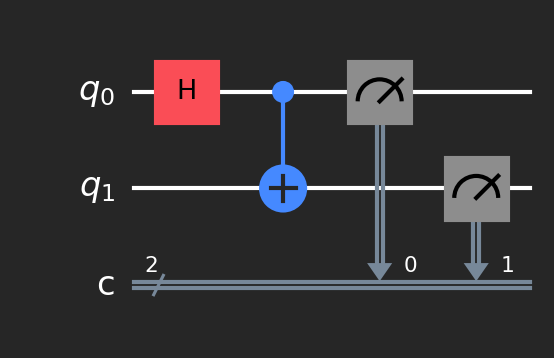

In [ ]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw()

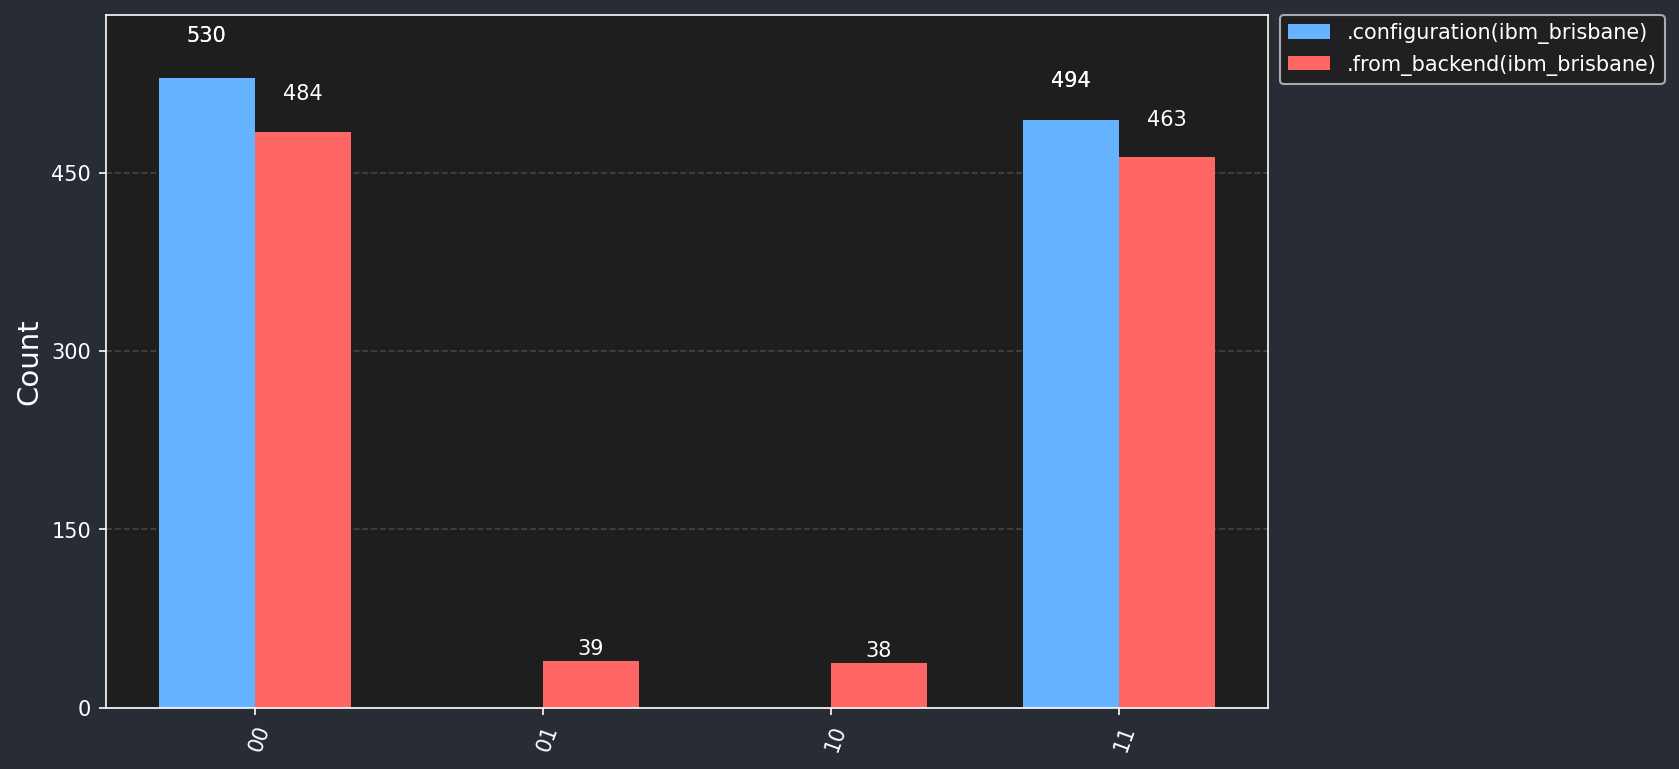

In [ ]:
transpiled_config = transpile(qc, backend=noisy_simulator_from_config)
result_config = noisy_simulator_from_config.run(transpiled_config, shots = 1024).result()
counts_config = result_config.get_counts()

transpiled_noisy = transpile(qc, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_config, counts_noisy], legend=[f'.configuration({real_backend.name})', f'.from_backend({real_backend.name})'], color = ['#66b3ff', "#ff6666"])


In [24]:
print(noisy_simulator_from_config.configuration().to_dict())
print(noisy_simulator.configuration().to_dict())

{'backend_name': 'ibm_brisbane', 'backend_version': '1.1.171', 'n_qubits': 127, 'basis_gates': ['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'initialize', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_

Repare aqui que ao rodar a comparação entre noisy_simulator_from_config (.configuration())e noisy_simulator (.from_backend()), temos resultados bastante distintos, o noisy_simulator_from_config não possui um modelo de noise, apesar de possuir a mesma configuração do noisy_simulator. 

---

### Proprieties

Contem as informações presentes sobre ruido do backend escolhido

- backend_name
- backend_version
- last_update_date
- qubits : Readout Errors, Tempo de Decoerência e Relaxamento 
- gates : Error, Noise Model e Duração do Gate
- general

In [25]:
print(simulator_aer.properties())

None


In [26]:
brisbane_proprieties = noisy_simulator.properties()
brisbane_proprieties_dict = brisbane_proprieties.to_dict()

print(brisbane_proprieties_dict)

print(f"\nLista de propriedades : \n")


print(*list(f"•{a}" for a in brisbane_proprieties_dict.keys()), sep='\n')

{'backend_name': '', 'backend_version': '', 'last_update_date': None, 'qubits': [[{'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685026, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.0341796875}, {'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685027, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685028, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.0234375}, {'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685029, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685029, tzinfo=datetime.timezone.utc), 'name': 'readout_error', 'unit': '', 'value': 0.006591796875}, {'date': datetime.datetime(2025, 8, 1, 14, 43, 24, 685030, tzinfo=datetime.timezone.utc), 'name': 'readout_length', 'unit': 's', 'value': 1.3e-06}], [{'date': datetim

In [27]:
noisy_simulator = AerSimulator.from_backend(real_backend)
noisy_simulator_proprieties_config = AerSimulator(configuration = brisbane_config, properties = brisbane_proprieties)

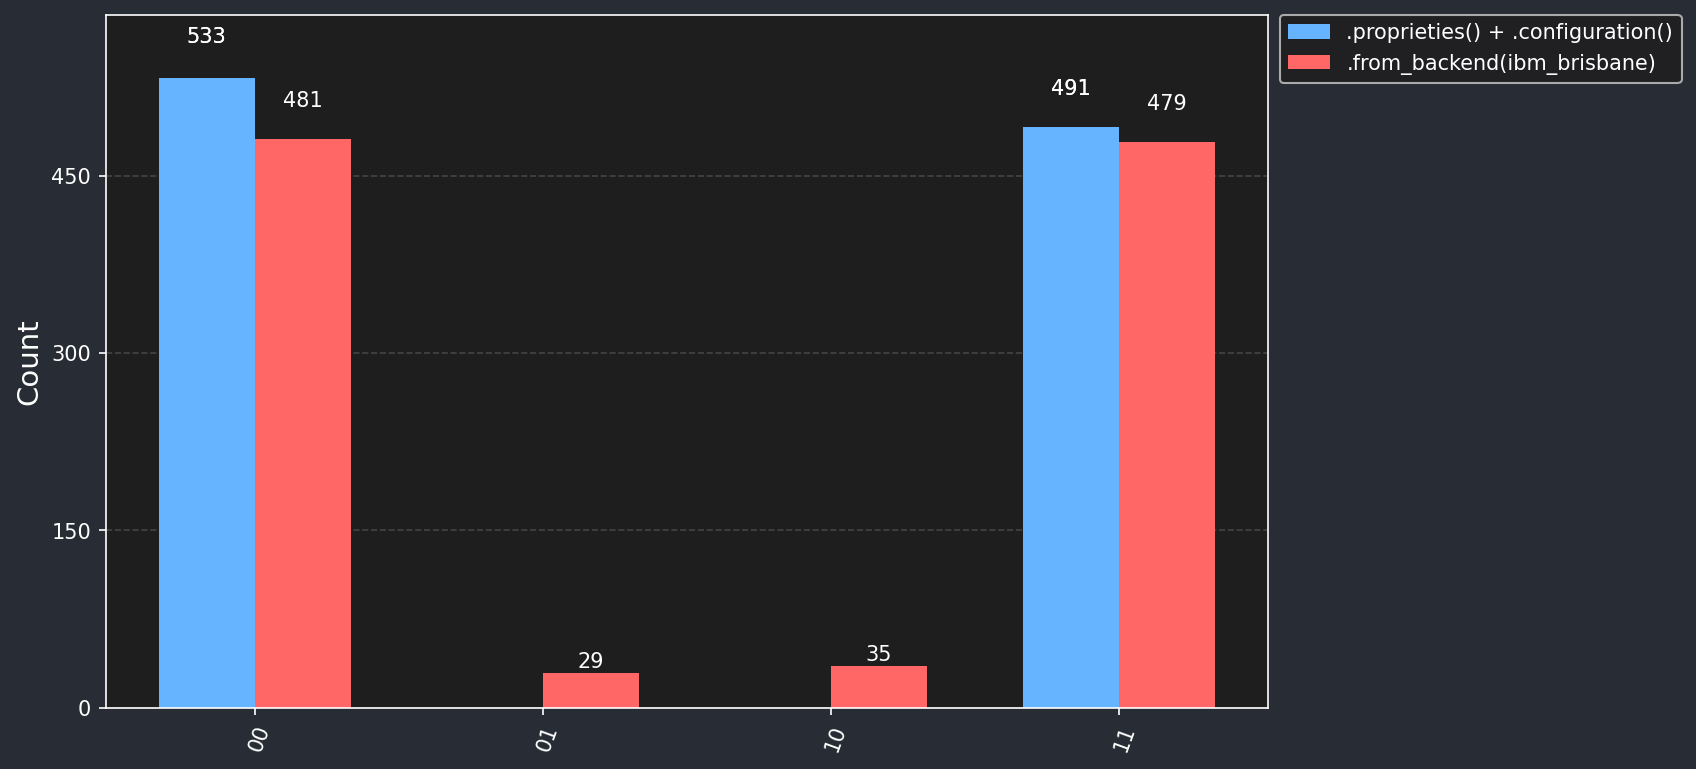

In [ ]:
transpiled_prop = transpile(qc, backend=noisy_simulator_proprieties_config)
result_prop = noisy_simulator_proprieties_config.run(transpiled_prop, shots = 1024).result()
counts_prop = result_prop.get_counts()

transpiled_noisy = transpile(qc, noisy_simulator)
result_noisy = noisy_simulator.run(transpiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts_prop, counts_noisy], legend=[f'.proprieties() + .configuration()', f'.from_backend({real_backend.name})'], color = ['#66b3ff', "#ff6666"])

Novamente podemos perceber que o gráfico utilizando o .proprieties() + .configuration() é ativamente diferente do .from_backend(). Isso se deve pelo motivo de não termos fornecido um NoiseModel em Backend_Options para o AerSimulator, fornecer o .proprieties() + .configuration() é apenas uma medida de DOCUMENTAÇÃO, e não é responsável pelo modelo de erros utilizado.

---

### Provider

Não tem utilidade, não precisamos de um provider para chamar o backend do AerSimulator, já que ele roda localmente (DeprecationWarning).

In [29]:
AerSimulator().available_devices()

('CPU',)

In [30]:
AerProvider().backends()

/tmp/ipykernel_1700/2100249447.py:1: DeprecationWarning: The class ``qiskit.providers.provider.Provider`` is deprecated as of qiskit 1.1. It will be removed no earlier than 3 months after the release date. The abstract Provider and ProviderV1 classes are deprecated and will be removed in 2.0. You can just remove it as the parent class and a `get_backend` method that returns the backends from `self.backend`.
  AerProvider().backends()


[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

---

### Target


O target é uma maneira de providenciar várias informações do Backend, assim como um conjunto do .configuration() e .properties()

In [31]:
print(*list(f"{a}" for a in AerSimulator().target), sep = ", \t")

save_density_matrix, 	save_state, 	r, 	mcx, 	mcphase, 	initialize, 	p, 	save_expval_var, 	save_amplitudes, 	mcrz, 	ryy, 	while_loop, 	cp, 	sxdg, 	delay, 	mcu3, 	mcsx, 	cu2, 	ccx, 	u2, 	continue_loop, 	ccz, 	u3, 	multiplexer, 	rzz, 	cu, 	for_loop, 	rxx, 	y, 	break_loop, 	csx, 	u, 	save_expval, 	cy, 	unitary, 	quantum_channel, 	z, 	rzx, 	mcp, 	crx, 	mcswap, 	superop, 	x, 	qerror_loc, 	mcu2, 	swap, 	mcr, 	save_unitary, 	cu1, 	h, 	set_density_matrix, 	sx, 	s, 	tdg, 	roerror, 	ecr, 	set_stabilizer, 	rz, 	save_statevector, 	mcz, 	sdg, 	mcu, 	cry, 	save_superop, 	save_amplitudes_sq, 	save_stabilizer, 	measure, 	cu3, 	crz, 	save_statevector_dict, 	save_matrix_product_state, 	mcry, 	mcx_gray, 	mcu1, 	ry, 	set_unitary, 	rx, 	if_else, 	t, 	set_superop, 	id, 	cswap, 	diagonal, 	save_clifford, 	mcy, 	u1, 	set_matrix_product_state, 	mcrx, 	save_probabilities, 	reset, 	cz, 	switch_case, 	kraus, 	cx, 	set_statevector, 	save_probabilities_dict, 	pauli


In [32]:
print(AerSimulator().target)

Target
Number of qubits: 29
Instructions:
	save_density_matrix
	save_state
	r
	mcx
	mcphase
	initialize
	p
	save_expval_var
	save_amplitudes
	mcrz
	ryy
	while_loop
	cp
	sxdg
	delay
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
		(5,)
		(6,)
		(7,)
		(8,)
		(9,)
		(10,)
		(11,)
		(12,)
		(13,)
		(14,)
		(15,)
		(16,)
		(17,)
		(18,)
		(19,)
		(20,)
		(21,)
		(22,)
		(23,)
		(24,)
		(25,)
		(26,)
		(27,)
		(28,)
	mcu3
	mcsx
	cu2
	ccx
	u2
	continue_loop
	ccz
	u3
	multiplexer
	rzz
	cu
	for_loop
	rxx
	y
	break_loop
	csx
	u
	save_expval
	cy
	unitary
	quantum_channel
	z
	rzx
	mcp
	crx
	mcswap
	superop
	x
	qerror_loc
	mcu2
	swap
	mcr
	save_unitary
	cu1
	h
	set_density_matrix
	sx
	s
	tdg
	roerror
	ecr
	set_stabilizer
	rz
	save_statevector
	mcz
	sdg
	mcu
	cry
	save_superop
	save_amplitudes_sq
	save_stabilizer
	measure
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
		(5,)
		(6,)
		(7,)
		(8,)
		(9,)
		(10,)
		(11,)
		(12,)
		(13,)
		(14,)
		(15,)
		(16,)
		(17,)
		(18,)
		(19,)
		(20,)
		(21,)
		(22,)
		(23,)
		(24,)
	

In [33]:
import inspect

brisbane_target = real_backend.target

print(*[f"• {a}" for a in dir(brisbane_target) if not a.startswith('_')], sep = "\n")

• acquire_alignment
• add_instruction
• build_coupling_map
• concurrent_measurements
• description
• dt
• durations
• from_configuration
• get
• get_calibration
• get_non_global_operation_names
• granularity
• has_calibration
• instruction_properties
• instruction_schedule_map
• instruction_supported
• instructions
• items
• keys
• min_length
• num_qubits
• operation_from_name
• operation_names
• operation_names_for_qargs
• operations
• operations_for_qargs
• physical_qubits
• pulse_alignment
• qargs
• qargs_for_operation_name
• qubit_properties
• timing_constraints
• update_from_instruction_schedule_map
• update_instruction_properties
• values


In [34]:
print(f"operation_names : {brisbane_target.operation_names}")
print(f"granularity : {brisbane_target.granularity}")
print(f"dt : {brisbane_target.dt}")

operation_names : dict_keys(['id', 'rz', 'sx', 'x', 'ecr', 'reset', 'measure', 'delay'])
granularity : 8
dt : 5e-10


---

### Backend Options

Essas opções de Backend Adicionais permitem uma configuração mais aprofundada do simulador


- method : Define qual algoritmo matemático o simulador usará.
- device : Escolha entre CPU (padrão) ou GPU.
- precision : Escolha entre 'double' (padrão) e 'single'.
- zero_threshold : Limite abaixo do qual as probabilidades são arredondadas para zero.
- enable_truncation : Automaticamente remove qubits desnecessários (Default: True).
- executor : Gerente de tarefas para os threads. [Guide](https://medium.com/qiskit/improve-the-performance-of-your-multi-circuit-simulations-using-qiskit-aer-with-dask-clusters-b4e47fad6cf0)
- max_parallel_threads : Controla quantos núcleos da sua CPU a simulação pode usar.
- max_memory_mb : Define um limite de memória RAM que a simulação pode usar. 
- max_job_size e max_shot_size : Separa o circuito em subjobs no executor.

- noise_model : Modelo de Noise a ser utilizado (Configurar .taget() ou .from_backend()).
- basis_gates : Para configuração manual do noise model, determina os gates com noise.

---


### Method 

Define qual algoritmo matemático o simulador usará.

- automatic : 

Método padrão do simulador, determina o algoritmo com base no circuito

- statevector : 

Amostra resultados de medição em circuitos ideais com todas as medições no final do circuito. Para simulações com ruído, cada shot amostra um circuito ruidoso gerado aleatoriamente a partir do modelo de ruído. Uma simulação que armazena e manipula o vetor de estado completo do sistema quântico em um formato denso (um grande array de números complexos). Perfeito para simular circuitos sem ruído para obter as probabilidades exatas e o estado quântico final. Seu resultado é um vetor de estado.

- density_matrix : 

Uma simulação que armazena e manipula a matriz de densidade do sistema. A matriz de densidade é uma representação mais geral de um estado quântico que pode descrever sistemas com incerteza clássica, como os que são submetidos a ruído. 

- stabilizer: 

Um simulador extremamente eficiente para circuitos quânticos de Clifford (Gates CNOT, Hadamard e S). Ele não usa o vetor de estado completo, mas uma representação matemática muito mais compacta. Pode simular ruído com um noise_model de Clifford

- extended_stabilizer : 

stabilizer com circuitos de Clifford + T (gate de rotação de π/8). Pode ser utilizado quando o circuito é muito grande para o statevector, mas é composto majoritariamente por portas de Clifford.

- matrix_product_state ([MPS](https://www.youtube.com/watch?v=W_IBEAzqm4U)):

Um simulador que usa uma representação de rede tensorial para o vetor de estado. Essa representação é muito eficiente em termos de memória para estados quânticos que possuem entrelaçamento limitado.

- unitary : 

Em vez de simular a evolução de um estado quântico, este método calcula a matriz unitária que representa o circuito inteiro. Ele não simula um estado inicial passando pelo circuito, mas sim o próprio operador matemático do circuito, apenas para circuitos ideais e não suporta medição, reset ou ruído. Seu resultado é um operador, uma matriz unitária.

- superop ([Tensor networks and graphical calculus for open quantum systems
](https://arxiv.org/pdf/1111.6950)): 

Calcula o superoperador do circuito, que é a representação matricial de um canal quântico. Pode simular portas ideais e com ruído, e também a operação de reset, mas não suporta medição. 

- tensor_network : 

Um simulador de propósito mais geral baseado em redes tensorais que pode simular tanto o vetor de estado quanto a matriz de densidade. Apenas para `device = "GPU"`. 

In [40]:
def clifford_qc(num_qubits: int, depth: int):

    qc = QuantumCircuit(num_qubits)

    qc.h(range(num_qubits))

    for level in range(depth):

        for i in range(num_qubits):
        
            if i % 2 == 0:
                qc.s(i)
        
            else:
                qc.sdg(i)
        
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.cx(num_qubits - 1, 0)
    
    qc.measure_all()

    return qc

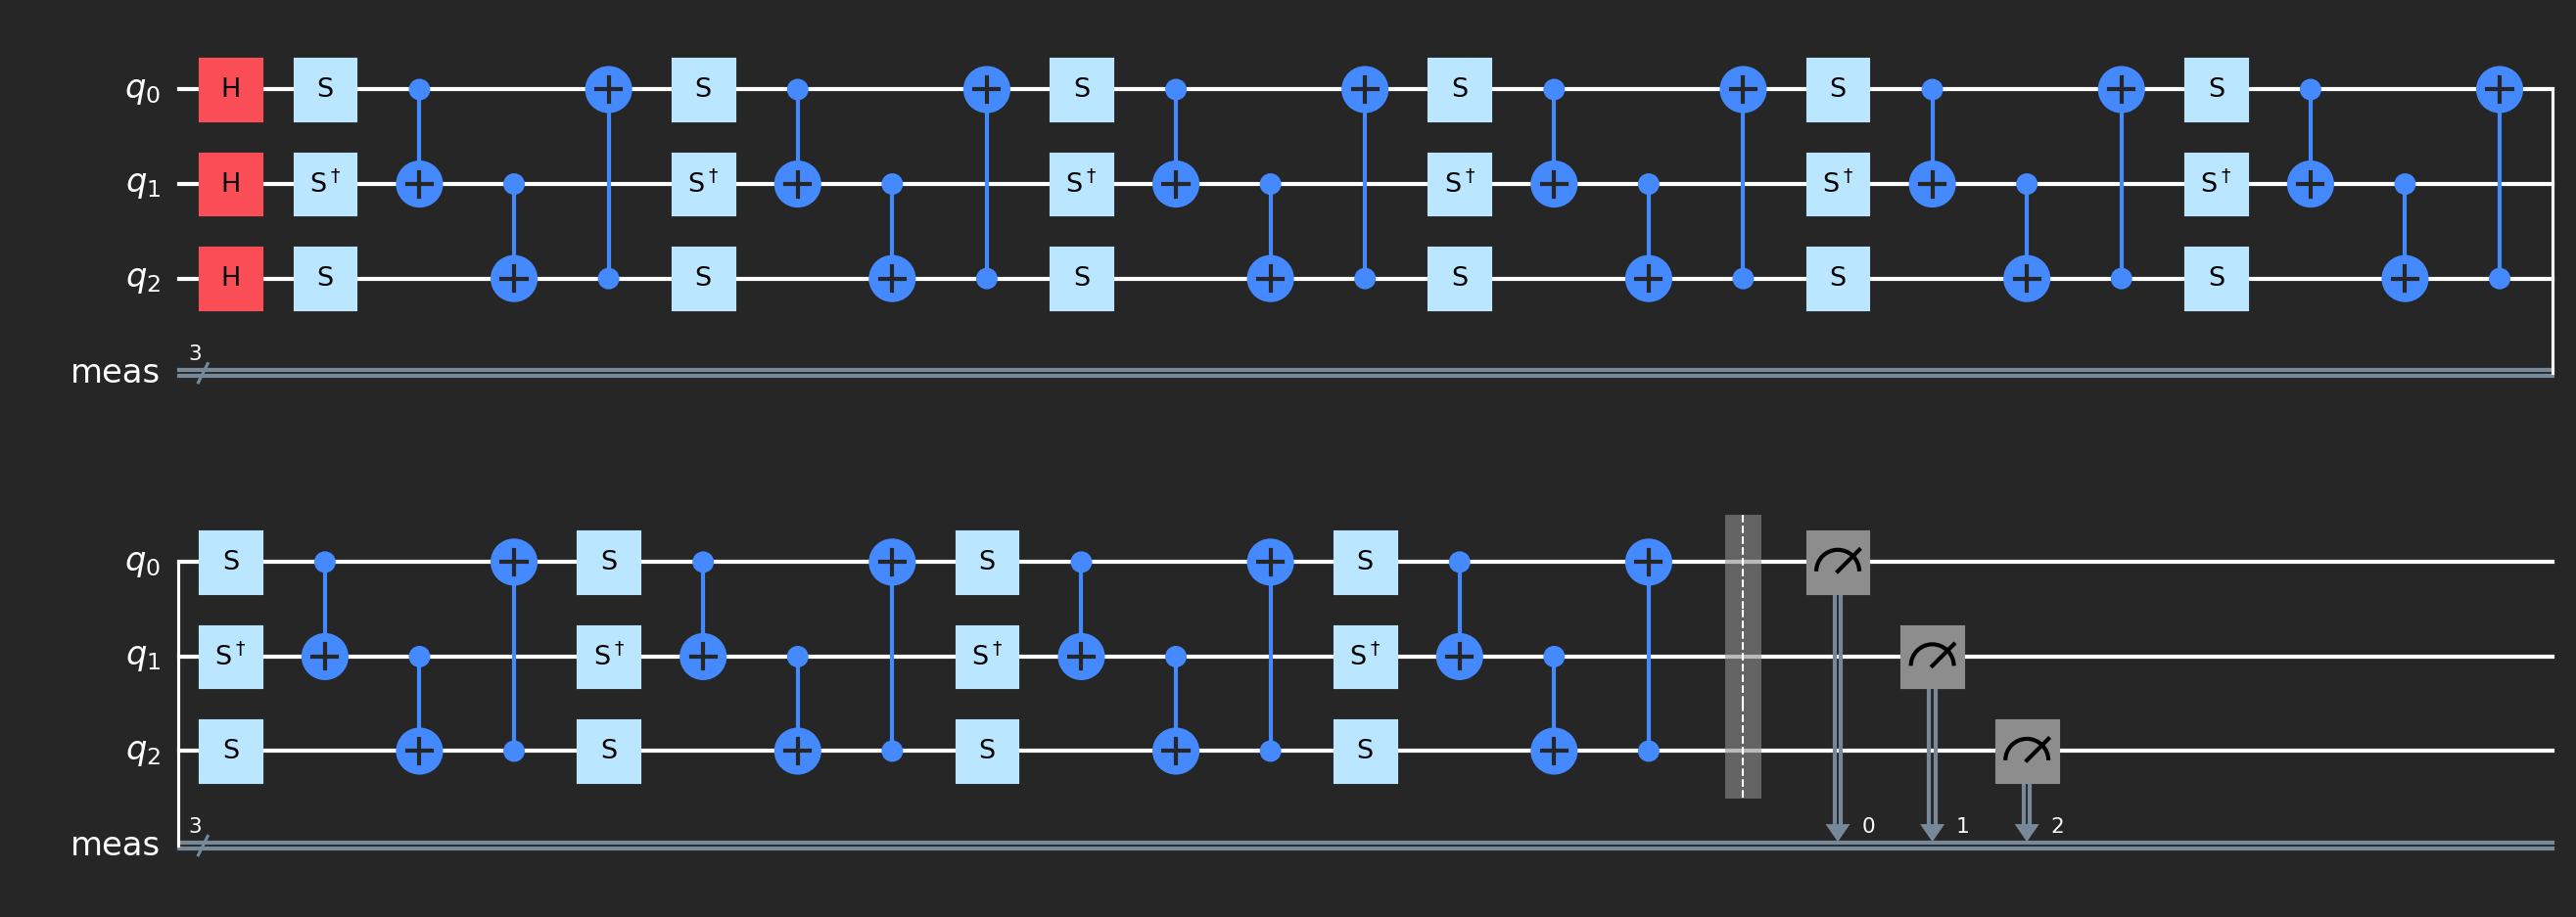

In [41]:
qc = clifford_qc(3, 10)

qc.draw()

In [ ]:
def histogram(num_qubits, deapth, shots):

    results = {}

    qc = clifford_qc(num_qubits, deapth)

    start_time = time.time()
    sim_statevector = AerSimulator(method='statevector')
    job_statevector = sim_statevector.run(qc, shots=shots)
    counts_statevector = job_statevector.result().get_counts(0)
    end_time = time.time()
    results["statevector"] = [counts_statevector, end_time - start_time]

    start_time = time.time()
    sim_density_matrix = AerSimulator(method='density_matrix')
    job_density_matrix = sim_density_matrix.run(qc, shots=shots)
    counts_density_matrix = job_density_matrix.result().get_counts(0)
    end_time = time.time()
    results["density_matrix"] = [counts_density_matrix, end_time - start_time]

    start_time = time.time()
    sim_stabilizer = AerSimulator(method='stabilizer')
    job_stabilizer = sim_stabilizer.run(qc, shots=shots)
    counts_stabilizer = job_stabilizer.result().get_counts(0)
    end_time = time.time()
    results["stabilizer"] = [counts_stabilizer, end_time - start_time]

    start_time = time.time()
    sim_extended_stabilizer = AerSimulator(method='extended_stabilizer')
    job_extended_stabilizer = sim_extended_stabilizer.run(qc, shots=shots)
    counts_extended_stabilizer = job_extended_stabilizer.result().get_counts(0)
    end_time = time.time()
    results["extended_stabilizer"] = [counts_extended_stabilizer, end_time - start_time]

    start_time = time.time()
    sim_matrix_product_state = AerSimulator(method='matrix_product_state')
    job_matrix_product_state = sim_matrix_product_state.run(qc, shots=shots)
    counts_matrix_product_state = job_matrix_product_state.result().get_counts(0)
    end_time = time.time()
    results["matrix_product_state"] = [counts_matrix_product_state, end_time - start_time]

    sorted_results = sorted(results.items(), key=lambda item: item[1][1])
    sorted_counts = [item[1][0] for item in sorted_results]
    sorted_legends = [f"{item[0]} ({item[1][1]:.4f}s)" for item in sorted_results]
    
    return sorted_counts, sorted_legends, sorted_results

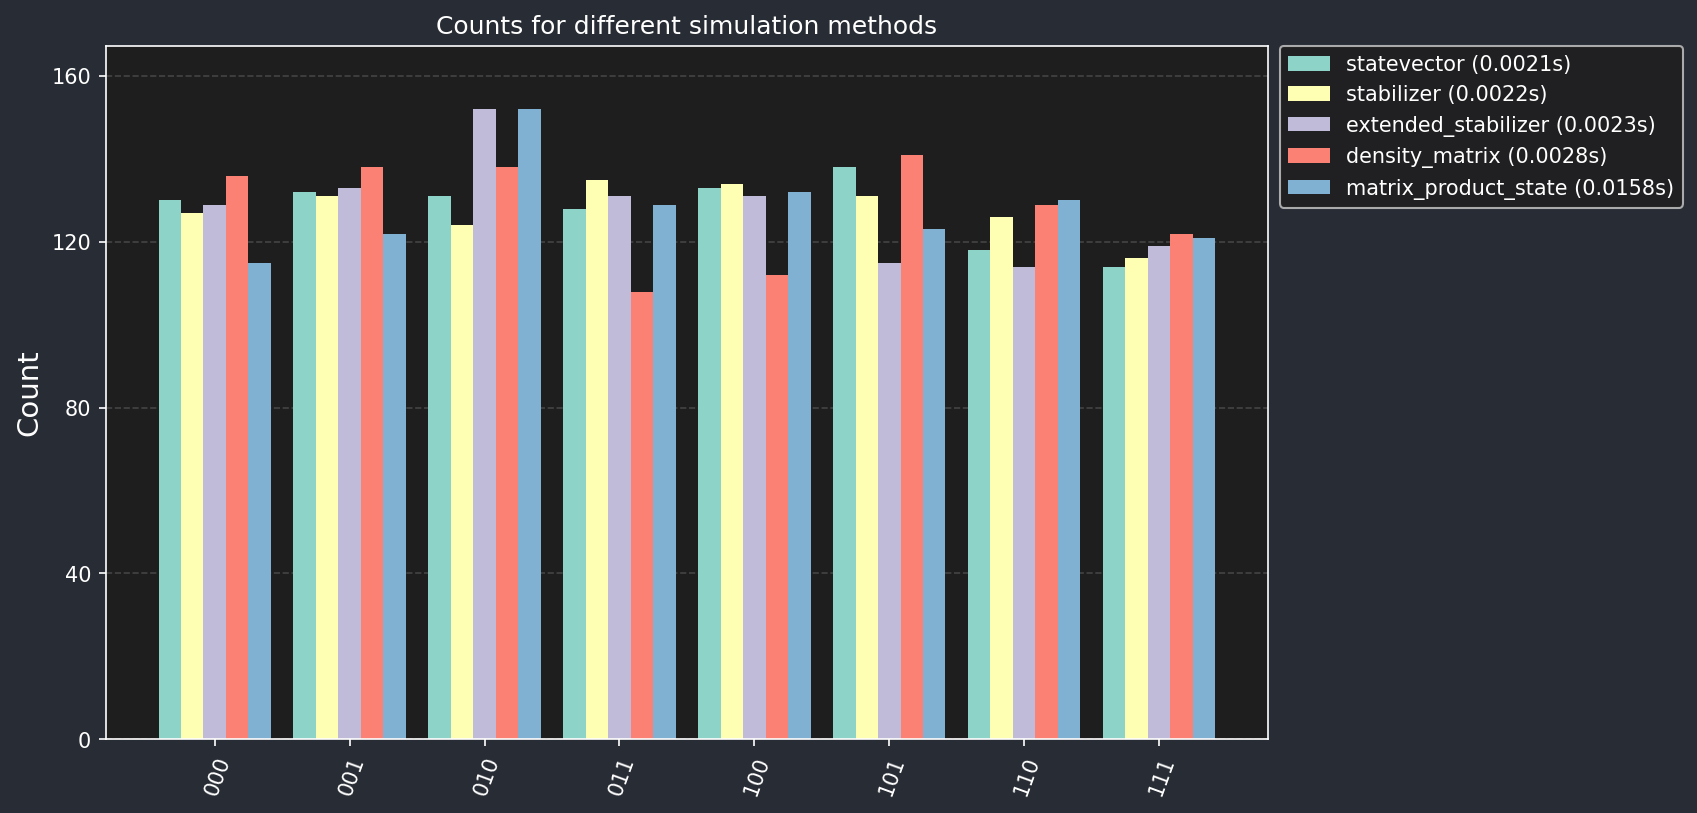

In [56]:
num_qubits, deapth = 3, 10
shots = 1024

sorted_counts, sorted_legends, sorted_results = histogram(num_qubits, deapth, shots)

plot_histogram(sorted_counts, legend=sorted_legends, title="Counts for different simulation methods", bar_labels = False)

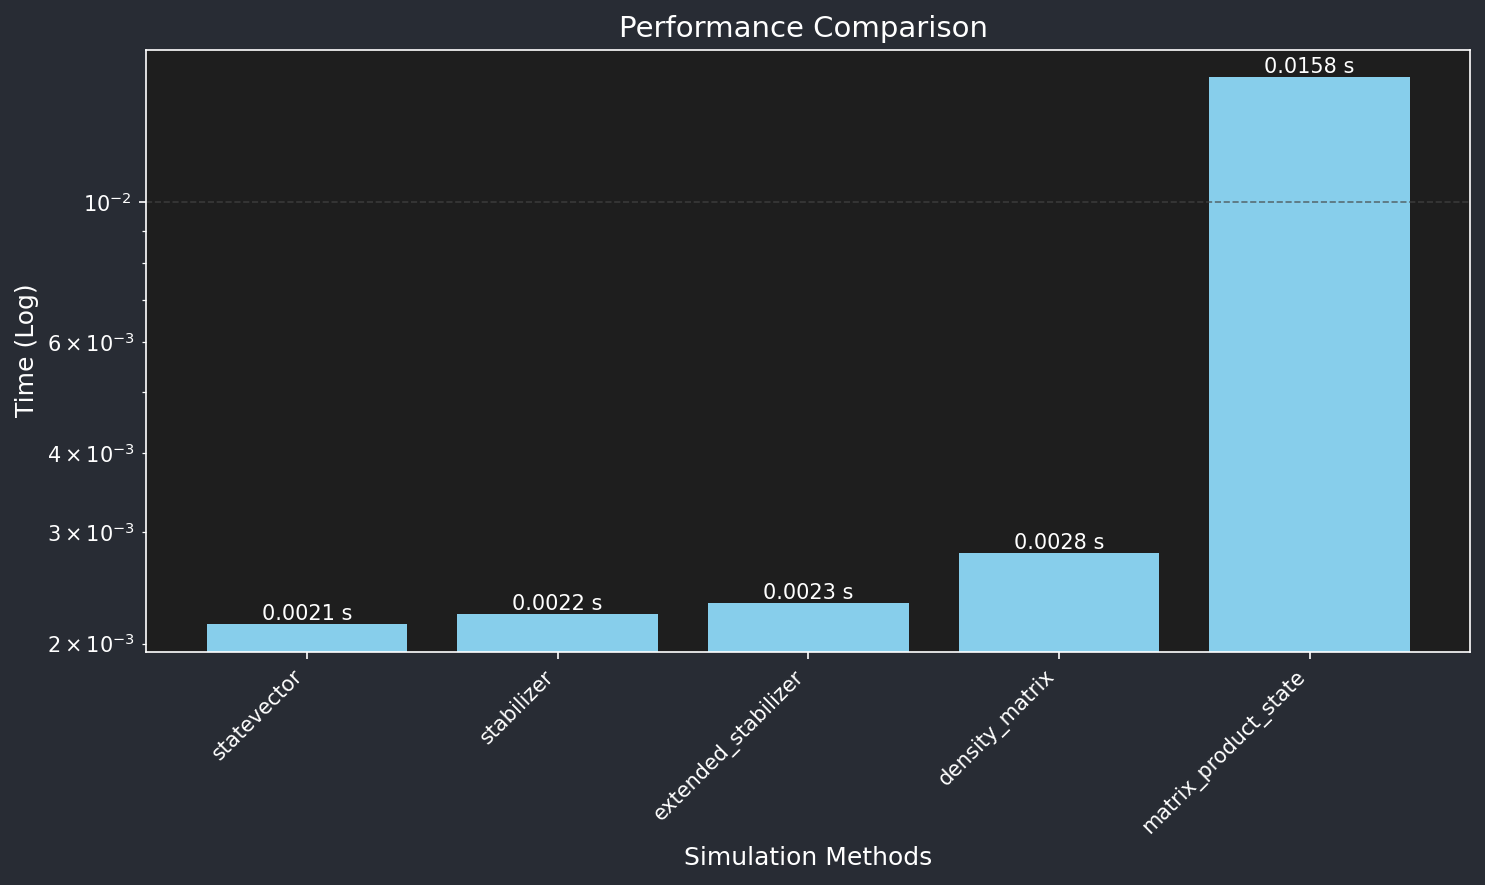

In [61]:
method_names = [item[0] for item in sorted_results]
execution_times = [item[1][1] for item in sorted_results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(method_names, execution_times, color='skyblue')
ax.set_xlabel('Simulation Methods', fontsize=12)
ax.set_ylabel('Time (Log)', fontsize=12)
ax.set_title('Performance Comparison ', fontsize=14)
ax.set_yscale('log') 
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f} s', va='bottom', ha='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

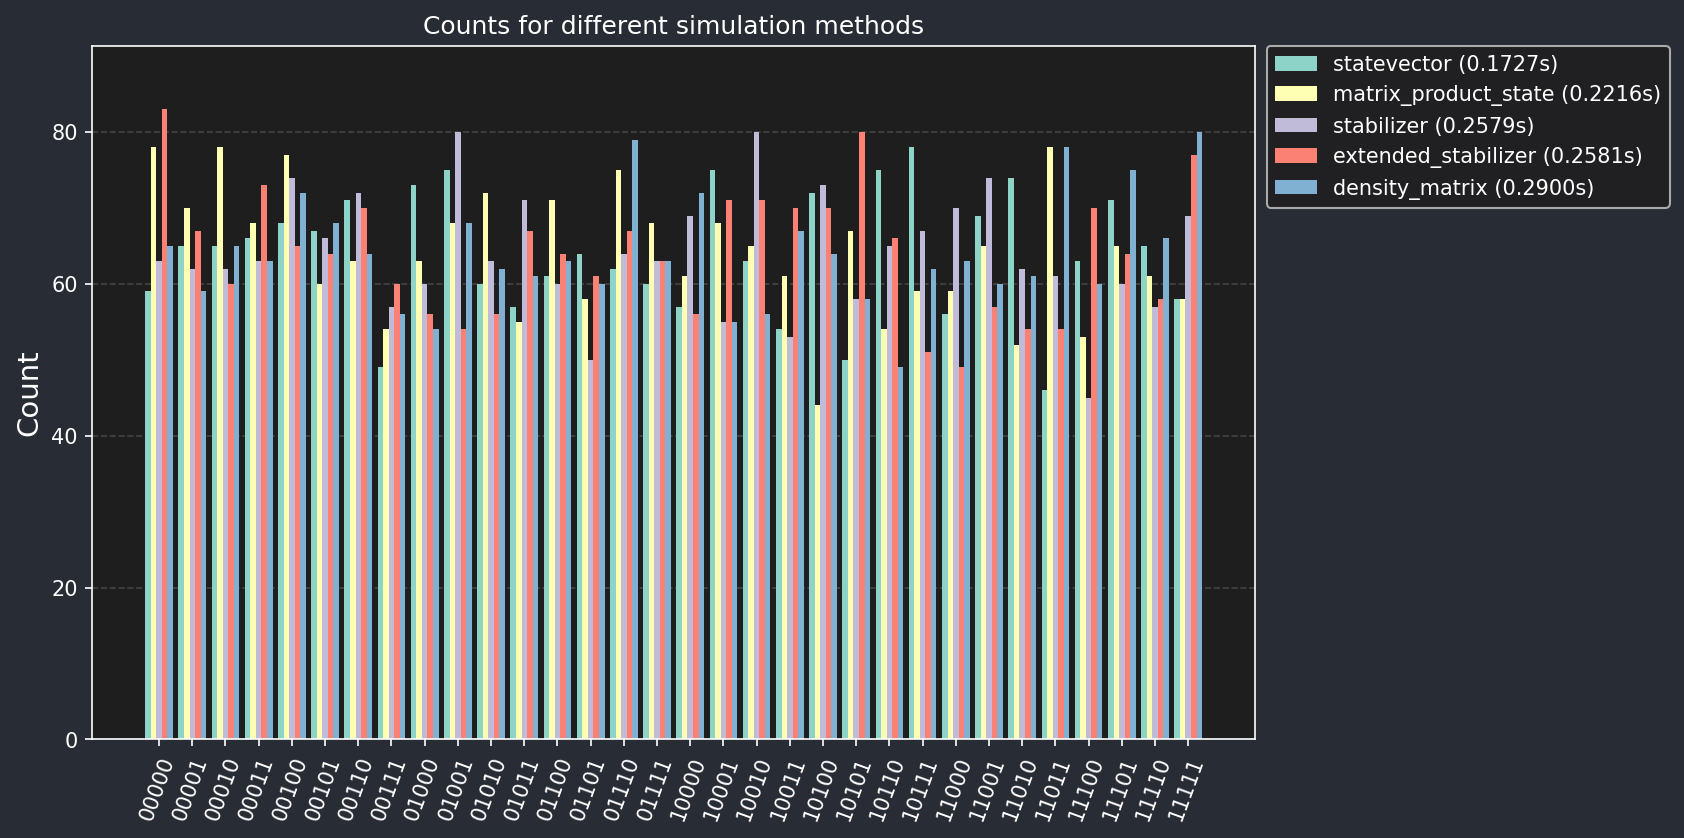

In [71]:
num_qubits, deapth = 5, 2000
shots = 2048

sorted_counts, sorted_legends, sorted_results = histogram(num_qubits, deapth, shots)

plot_histogram(sorted_counts, legend=sorted_legends, title="Counts for different simulation methods", bar_labels = False)

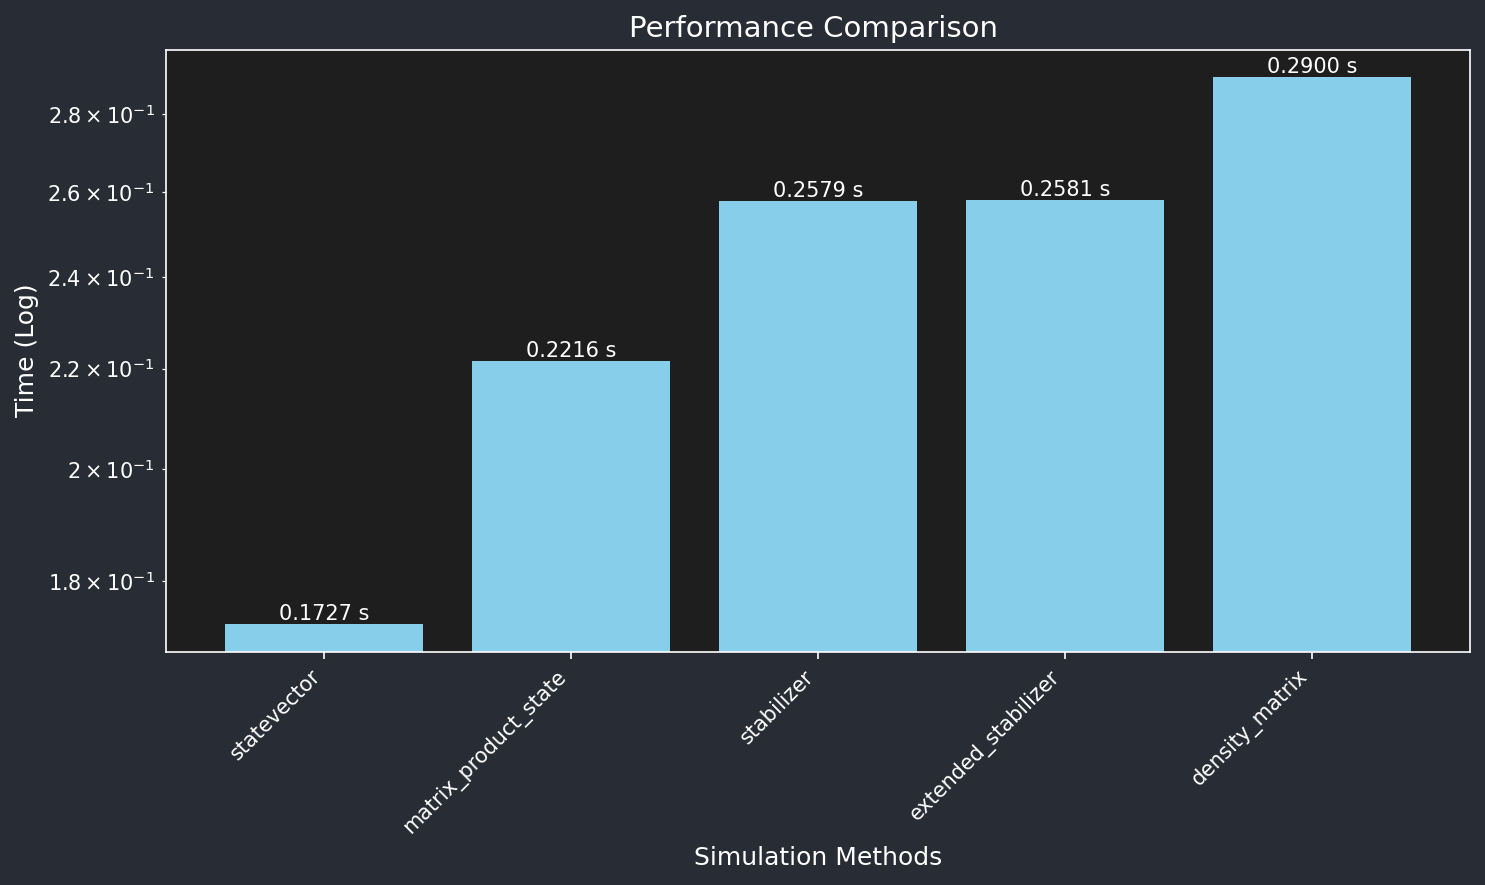

In [72]:
method_names = [item[0] for item in sorted_results]
execution_times = [item[1][1] for item in sorted_results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(method_names, execution_times, color='skyblue')
ax.set_xlabel('Simulation Methods', fontsize=12)
ax.set_ylabel('Time (Log)', fontsize=12)
ax.set_title('Performance Comparison ', fontsize=14)
ax.set_yscale('log') 
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f} s', va='bottom', ha='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()